In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

### Load Data


In [ ]:
df = pd.read_csv('METABRIC_RNA_Mutation.csv', low_memory=False)


C:\Users\Newton\AppData\Local\Temp\ipykernel_10616\4151436912.py:1: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('METABRIC_RNA_Mutation.csv')


### Selecting columns


In [4]:
my_columns= ['age_at_diagnosis','tumor_size','er_status','overall_survival']
sub_df = df[my_columns].copy()

### Cleaninng Data


In [7]:
# So after class i noticed  there my be missing data
#going to fill with median Value for the column

my_columns = ['age_at_diagnosis', 'tumor_size', 'er_status', 'pr_status', 'overall_survival']
sub_df = df[my_columns].copy()

# tried to run without a placeholder 3/14/26
# come back and did some research on scii kit for text it needs a postive value
# as a place Holder 3/16/26

sub_df['age_at_diagnosis'] = sub_df['age_at_diagnosis'].fillna(sub_df['age_at_diagnosis'].median())
sub_df['tumor_size'] = sub_df['tumor_size'].fillna(sub_df['tumor_size'].median())
sub_df['er_status'] = sub_df['er_status'].fillna('Positive')
sub_df['pr_status'] = sub_df['pr_status'].fillna('Positive')




### Encoding



In [8]:
# Now we have a clean data set to work with
# We now must convert text to numbers (Lesson 5 speaks on this)
#3/20/26 update
# Converting ER Status
er_numbers = []
for index, row in sub_df.iterrows():
    if row['er_status'] == 'Positive':
        er_numbers.append(1)
    else:
        er_numbers.append(0)
sub_df['er_status'] = er_numbers

# Converting PR Status
pr_numbers = []
for index, row in sub_df.iterrows():
    if row['pr_status'] == 'Positive':
        pr_numbers.append(1)
    else:
        pr_numbers.append(0)
sub_df['pr_status'] = pr_numbers

### Splitting the Data


In [9]:
# classifiying out inputs
# inputs(x) and outputs(y)

x = sub_df[['age_at_diagnosis', 'tumor_size', 'er_status', 'pr_status']]
y = sub_df['overall_survival']

# now we have input and outputs lets assign training data
# we usually do about 20% for testing and 80% for training

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# 42 for random states because it the value of the world

### Training The Model




In [10]:
Model = LogisticRegression()
Model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### evaluating the model

predictions = model.predit(X_test)
score = accuracry(y_test, predictions)

print(score)

This part above was because i kept forgetting it


In [13]:
model = LogisticRegression()
model.fit(X_train, y_train)

## predict and Evaluate the model

predictions = model.predict(X_test)
score = accuracy_score(y_test, predictions)

#Boom Checking the accuracy of our model
print("Accuracy:", score)


Accuracy: 0.6587926509186351


### Create the Figure

Number of patients who lived: 801
Number of patients who died: 1103


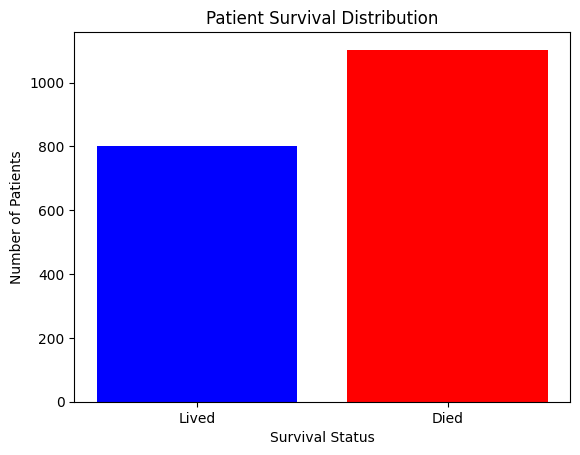

<Figure size 640x480 with 0 Axes>

In [14]:
lived_count = 0
died_count = 0

for index, row in sub_df.iterrows():
    if row['overall_survival'] == 1:
        lived_count += 1
    else:
        died_count += 1

print("Number of patients who lived:", lived_count)
print("Number of patients who died:", died_count)

#create our bar chart

labels = ['Lived', 'Died']
counts = [lived_count, died_count]

plt.bar(labels, counts, color=['blue', 'red'])
plt.xlabel('Survival Status')
plt.ylabel('Number of Patients')
plt.title('Patient Survival Distribution')
plt.show()

plt.savefig('survival_distribution.png')